In [56]:
import os
from pathlib import Path
from dotenv import load_dotenv
from tqdm import tqdm
import geopandas as gpd
import pandas as pd
from shapely.ops import unary_union

In [4]:
load_dotenv()  # take environment variables from .env.

DATA_FOLDER = Path(os.getenv("DATA_FOLDER")) 
IMAGERY_FOLDER = DATA_FOLDER / "imagery" 
MASK_FOLDER = DATA_FOLDER / "geopackages"

building_height_path = MASK_FOLDER / "UK_building_height/gdb/tl/tl0045.gdb/a00000009.gdbtable"
building_footprint_path = MASK_FOLDER / "UK_open_map_local/TL/TL_Building.shp"

building_height_gpd = gpd.read_file(building_height_path)
building_footprint_gpd = gpd.read_file(building_footprint_path)

In [27]:
base_dir = MASK_FOLDER / "UK_building_height/gdb/"

In [ ]:
uk_building_height_folder = MASK_FOLDER / "UK_building_height/gdb/"

input_vector_dirs = [dir for dir in uk_building_height_folder.glob('*/') if dir.is_dir]

for tile_dir in tqdm(input_vector_dirs, desc='UK'):
    # print("--", tile_dir.stem)

    tiles_dirs = [dir for dir in tile_dir.glob('*/') if dir.is_dir]

    for small_tile in tqdm(tiles_dirs, desc='Tile'):
        # print("++", small_tile)
        out_name = "Building_height_" + small_tile.stem + '_dissolved.gpkg'
        # print(small_tile.stem)

        y = [x for x in small_tile.glob("*9.gdbtable")]
        if len(y) > 1:
            print(len(small_tile)) 

In [55]:
[x for x in small_tile.glob("*9.gdbtable")]

[PosixPath('/Users/ancazugo/Library/CloudStorage/GoogleDrive-acz25@cam.ac.uk/My Drive/PhD Thesis/data/geopackages/UK_building_height/gdb/tg/tg0000.gdb/a00000009.gdbtable')]

/var/folders/gr/150_8wbn02s9rdqqvb4pbblh0000gn/T/ipykernel_13104/3457835802.py:1: UserWarning: `keep_geom_type=True` in overlay resulted in 5 dropped geometries of different geometry types than df1 has. Set `keep_geom_type=False` to retain all geometries
  intersection_gpd = gpd.overlay(building_height_gpd, building_footprint_gpd, how='intersection')


<Axes: >

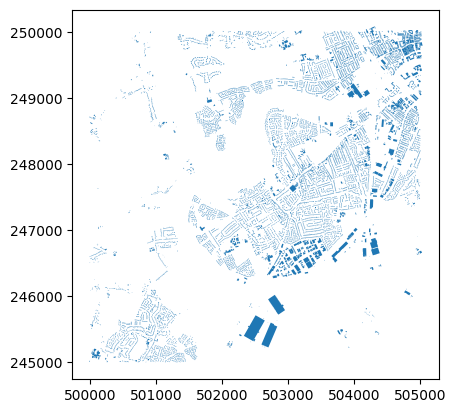

In [17]:
intersection_gpd = gpd.overlay(building_height_gpd, building_footprint_gpd, how='intersection')
intersection_gpd.plot()

In [18]:
intersection_gpd.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 21190 entries, 0 to 21189
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   os_topo_toid     21190 non-null  object        
 1   os_topo_version  21190 non-null  int64         
 2   bha_processdate  21190 non-null  datetime64[ns]
 3   tileref          21190 non-null  object        
 4   abshmin          21190 non-null  float64       
 5   absh2            20784 non-null  float64       
 6   abshmax          21190 non-null  float64       
 7   relh2            20784 non-null  float64       
 8   relhmax          21190 non-null  float64       
 9   bha_conf         21190 non-null  int64         
 10  ID               21190 non-null  object        
 11  FEATCODE         21190 non-null  int64         
 12  geometry         21190 non-null  geometry      
dtypes: datetime64[ns](1), float64(5), geometry(1), int64(3), object(3)
memory usage: 2.

In [23]:

# Assuming 'intersection_ab' is the GeoDataFrame resulting from the intersection operation

# Specify the columns for which to calculate mean, min, and max
columns_to_aggregate = ['abshmin', 'absh2', 'abshmax', 'relh2', 'relhmax']  # Replace with your actual column names

# Dissolve all features into a single MultiPolygon (this keeps disjoint features separate)
# and explode back into separate features
dissolved = building_height_gpd.dissolve().explode().reset_index(drop=True).drop(columns=columns_to_aggregate)

# Create a spatial join between the original intersection GeoDataFrame and the dissolved one
# to find which original polygons correspond to which dissolved ones
joined = gpd.sjoin(building_height_gpd, dissolved, how='left', op='within')

# Calculate mean, min, and max values for each group of original polygons
# that are now part of the same dissolved polygon
aggregated = joined.groupby(joined.index_right)[columns_to_aggregate].agg(['mean', 'min', 'max'])

# Flatten MultiIndex columns resulting from aggregation
aggregated.columns = ['_'.join(col).strip() for col in aggregated.columns.values]

# Merge the aggregated values back with the dissolved GeoDataFrame
dissolved_with_aggregates = dissolved.join(aggregated, how='left')

# 'dissolved_with_aggregates' now contains your dissolved polygons with mean, min, and max column values


/var/folders/gr/150_8wbn02s9rdqqvb4pbblh0000gn/T/ipykernel_13104/3365895433.py:8: FutureWarning: Currently, index_parts defaults to True, but in the future, it will default to False to be consistent with Pandas. Use `index_parts=True` to keep the current behavior and True/False to silence the warning.
  dissolved = building_height_gpd.dissolve().explode().reset_index(drop=True).drop(columns=columns_to_aggregate)
/Users/ancazugo/Documents/PhD_Thesis/Tree_detection/.venv/lib/python3.12/site-packages/IPython/core/interactiveshell.py:3517: FutureWarning: The `op` parameter is deprecated and will be removed in a future release. Please use the `predicate` parameter instead.
  if await self.run_code(code, result, async_=asy):


In [24]:
dissolved_with_aggregates

,os_topo_toid,os_topo_version,bha_processdate,tileref,bha_conf,geometry,abshmin_mean,abshmin_min,abshmin_max,absh2_mean,...,absh2_max,abshmax_mean,abshmax_min,abshmax_max,relh2_mean,relh2_min,relh2_max,relhmax_mean,relhmax_min,relhmax_max
0,osgb1000000032278707,2,2017-09-30,TL0045,99,"POLYGON ((500252.160 244996.750, 500255.200 24...",47.700001,47.700001,47.700001,51.400002,...,51.400002,55.200001,55.200001,55.200001,3.70,3.7,3.7,7.5,7.5,7.5
1,osgb1000000032278707,2,2017-09-30,TL0045,99,"POLYGON ((500000.000 245009.700, 499994.160 24...",48.500000,48.500000,48.500000,54.500000,...,54.500000,55.900002,55.900002,55.900002,6.00,6.0,6.0,7.4,7.4,7.4
2,osgb1000000032278707,2,2017-09-30,TL0045,99,"POLYGON ((500400.820 245045.910, 500398.880 24...",45.200001,45.200001,45.200001,52.500000,...,52.500000,53.500000,53.500000,53.500000,7.30,7.3,7.3,8.3,8.3,8.3
3,osgb1000000032278707,2,2017-09-30,TL0045,99,"POLYGON ((500244.280 245040.520, 500241.580 24...",48.700001,48.700001,48.700001,56.400002,...,56.400002,61.799999,61.799999,61.799999,7.70,7.7,7.7,13.1,13.1,13.1
4,osgb1000000032278707,2,2017-09-30,TL0045,99,"POLYGON ((500128.850 245059.060, 500129.290 24...",49.799999,49.799999,49.799999,52.599998,...,52.599998,55.299999,55.299999,55.299999,2.80,2.8,2.8,5.5,5.5,5.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13056,osgb1000000032278707,2,2017-09-30,TL0045,99,"POLYGON ((504930.990 249993.600, 504928.800 24...",29.900000,29.799999,30.000000,34.920000,...,40.599998,40.000000,35.099998,45.599998,5.02,2.9,10.7,10.1,5.3,15.8
13057,osgb1000000032278707,2,2017-09-30,TL0045,99,"POLYGON ((504987.700 249977.700, 504987.200 24...",30.349999,30.299999,30.400000,35.449999,...,35.799999,37.049999,36.599998,37.500000,5.10,4.7,5.5,6.7,6.3,7.1
13058,osgb1000000032278707,2,2017-09-30,TL0045,99,"POLYGON ((504938.000 249990.150, 504941.950 24...",29.900000,29.900000,29.900000,32.000000,...,32.000000,32.700001,32.700001,32.700001,2.10,2.1,2.1,2.8,2.8,2.8
13059,osgb1000000032278707,2,2017-09-30,TL0045,99,"POLYGON ((504997.900 250000.000, 504997.940 25...",30.349999,30.299999,30.400000,36.200001,...,37.200001,40.550001,39.900002,41.200001,5.85,4.9,6.8,10.2,9.6,10.8


In [25]:
dissolved_with_aggregates.to_file(MASK_FOLDER / "UK_building_height/example_self.gpkg")